# Relaxation Step

## Setting spontaneous curvature (Optional)

In [2]:
# import numpy as np
# from pathlib import Path
# from coat_test import get_force_density
# from plot import plot_coord_force, plot_coord_curve_force
# from automembrane.energy import OpenPlaneCurveMaterial
# from automembrane.geometry import OpenPlaneCurveGeometry

# file = Path('coordinates/Membrane_2018June_Tomo26_CME_Invagination.txt')
# N_node = 50
# img_id = 1
# file_path = os.path.join(f"dat/img_{img_id:02d}_{N_node}.npz")

# # Load coordinates and compute curvature
# data = np.load(file_path)
# coords = data['coords']
# coords = coords[-1]
# curvature = OpenPlaneCurveGeometry.edge_curvature(coords)
# spont_c = np.where(curvature < 0, curvature, 0)

# # Threshold for segment length
# threshold = 8  # Example threshold

# # Step 2: Find the indices of non-zero values
# non_zero_indices = np.where(spont_c != 0)[0]

# # Step 3: Identify continuous segments of non-zero values
# continuous_segments = np.split(non_zero_indices, np.where(np.diff(non_zero_indices) != 1)[0] + 1)

# # Step 4: Filter out segments whose lengths are less than the threshold
# filtered_spont_c = np.zeros_like(spont_c)  # Initialize with zeros
# for segment in continuous_segments:
#     if len(segment) >= threshold:
#         filtered_spont_c[segment] = spont_c[segment]  # Keep segments that meet the length threshold

# # Now, filtered_spont_c contains only the segments with lengths >= threshold
# print(filtered_spont_c)

[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -0.00378367 -0.00464475
 -0.00921239 -0.01124122 -0.02212562 -0.02543081 -0.01627631 -0.02374868
 -0.02127238 -0.0232576  -0.02524955 -0.03819423 -0.04195122 -0.02529692
 -0.01756467 -0.01079775 -0.0082175  -0.00725076 -0.00677715 -0.00994194
 -0.01085647 -0.00822513 -0.00523644  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ]


## Relaxation

In [20]:
from variation_relax import resample, relax_bending, relax_bending_log, preprocess_mesh
import os
import numpy as np
from pathlib import Path

# Data path
file = Path('coordinates/Membrane_2018June_Tomo26_CME_Invagination.txt')
img_id = 1

# Parameters
N_node = 100

params = {
    "Kb"      : 10,       # bending term weight
    "Ks"      : 10,       # surface tension term weight
    "Kr"      : 10,       # regularization term weight
    "k_d"     : 1,        # data fidelity term weight 
    "n_degree": 4,        # degree of the data term
    "dt"      : 1e-3,     # time step for forward Eulear
    "n_iter"  : int(3e5), # total iteration of forward Eulear
    "boundary": "pinned", # boundary condition
    "del_save": 1e3,
}

ori_coords, _ = preprocess_mesh(file, resample_geometry=True, n_vertices=N_node)

# cvt = -0.02
# spont_c = np.where(filtered_spont_c != 0, cvt, 0)

# Relax the curve by forward Eulear based on membrane energy
# coords, energy, forces = relax_bending_log(coords=spl_coords, data_points=ori_coords, spont_c=spont_c, **params)
# coords, energy, forces, length, curvat, dtdist = relax_bending_log(coords=ori_coords, data_points=ori_coords, **params)

output_keys = ["coords", "energy", "forces", "length", "curvat", "dtdist"]
result = dict(zip(output_keys, relax_bending_log(coords=ori_coords, data_points=ori_coords, **params)))

# Storing data
file_path = os.path.join(f"dat/v2/img_{img_id:02d}_{N_node}.npz")
# np.savez(file_path, ori_coords = ori_coords, coords = coords, energy=energy, forces=forces, length=length, curvat=curvat, dtdist=dtdist)
np.savez(file_path, ori_coords=ori_coords, **result)



max_H:  0.07904673428637368
ave_H:  0.0188878328344332
cleng:  499.5071408758895
kappa:  12.815938818028082
sigma:  0.020019733816947893


Energy relaxation:   0%|          | 0/300000 [00:00<?, ?it/s]

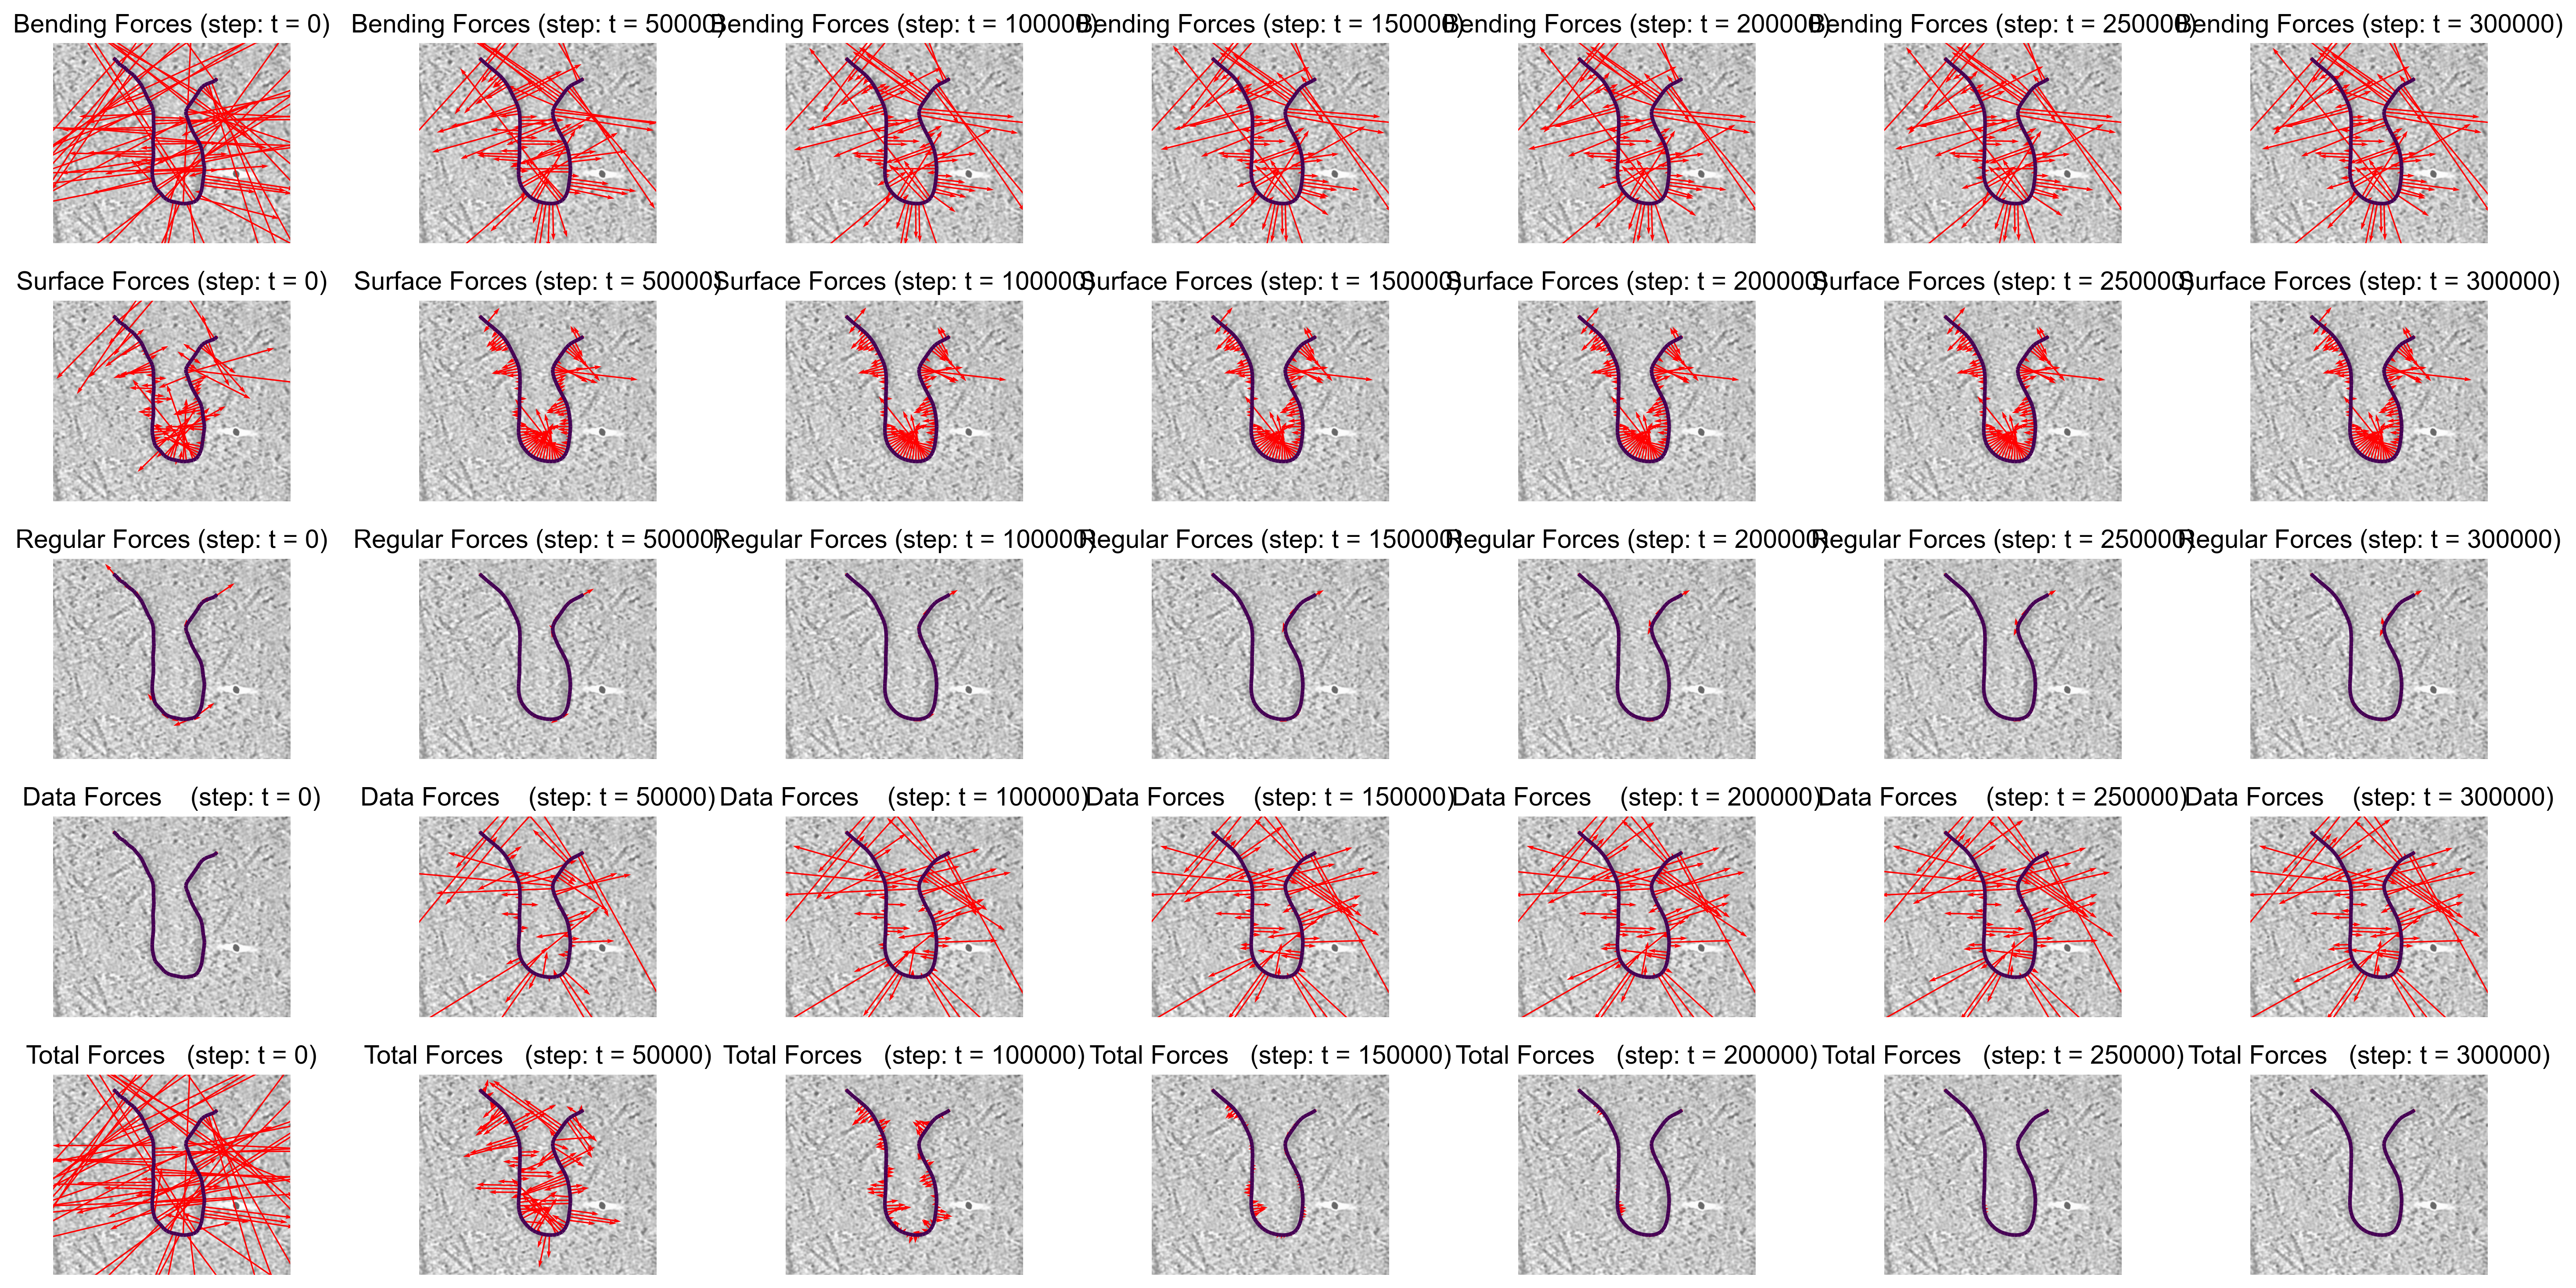

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from plot import plot_img_ax

file_stem = 'Membrane_2018June_Tomo26_CME_Invagination'
# N_node = 30
# img_id = 1
tot_iter = 3e5
del_show = 5e4
del_save = 1e3

# tot_iter = 1e5
# del_show = 2e4
# del_save = 1e3

scale = 1

interval = int(del_show/del_save)
n_show = int(tot_iter/del_show)+1
fig, axes = plt.subplots(5, n_show, figsize=(20, 10))

file_path = os.path.join(f"dat/v2/img_{img_id:02d}_{N_node}.npz")
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']

curves = np.zeros(N_node)
# curves = np.where(filtered_spont_c != 0, 1, 0)

for idx in range(0, n_show):

    n_iter = del_show * idx
    i = interval * idx
    total_forces = forces[i, 0] + forces[i, 1] + forces[i, 2] + forces[i, 3]
    
    # plot_img_ax(file_stem, coords[i], curves, forces[i, 0], ax=axes[0, idx], n_iter=n_iter, force_type="Bending Forces", scale=100, ori_coords = ori_coords)
    # plot_img_ax(file_stem, coords[i], curves, forces[i, 1], ax=axes[1, idx], n_iter=n_iter, force_type="Surface Forces", scale=100, ori_coords = ori_coords)
    # plot_img_ax(file_stem, coords[i], curves, forces[i, 2], ax=axes[2, idx], n_iter=n_iter, force_type="Regular Forces", scale=100, ori_coords = ori_coords)
    # plot_img_ax(file_stem, coords[i], curves, forces[i, 3], ax=axes[3, idx], n_iter=n_iter, force_type="Data Forces   ", scale=100, ori_coords = ori_coords)
    # plot_img_ax(file_stem, coords[i], curves, total_forces, ax=axes[4, idx], n_iter=n_iter, force_type="Total Forces  ", scale=100, ori_coords = ori_coords)

    plot_img_ax(file_stem, coords[i], curves, forces[i, 0], ax=axes[0, idx], n_iter=n_iter, force_type="Bending Forces", scale=scale)
    plot_img_ax(file_stem, coords[i], curves, forces[i, 1], ax=axes[1, idx], n_iter=n_iter, force_type="Surface Forces", scale=scale)
    plot_img_ax(file_stem, coords[i], curves, forces[i, 2], ax=axes[2, idx], n_iter=n_iter, force_type="Regular Forces", scale=scale)
    plot_img_ax(file_stem, coords[i], curves, forces[i, 3], ax=axes[3, idx], n_iter=n_iter, force_type="Data Forces   ", scale=scale)
    plot_img_ax(file_stem, coords[i], curves, total_forces, ax=axes[4, idx], n_iter=n_iter, force_type="Total Forces  ", scale=scale)


plt.tight_layout()
plt.savefig(f"figures/v2/relax/img{img_id:02d}_n{N_node}.png", dpi=300)
plt.show()


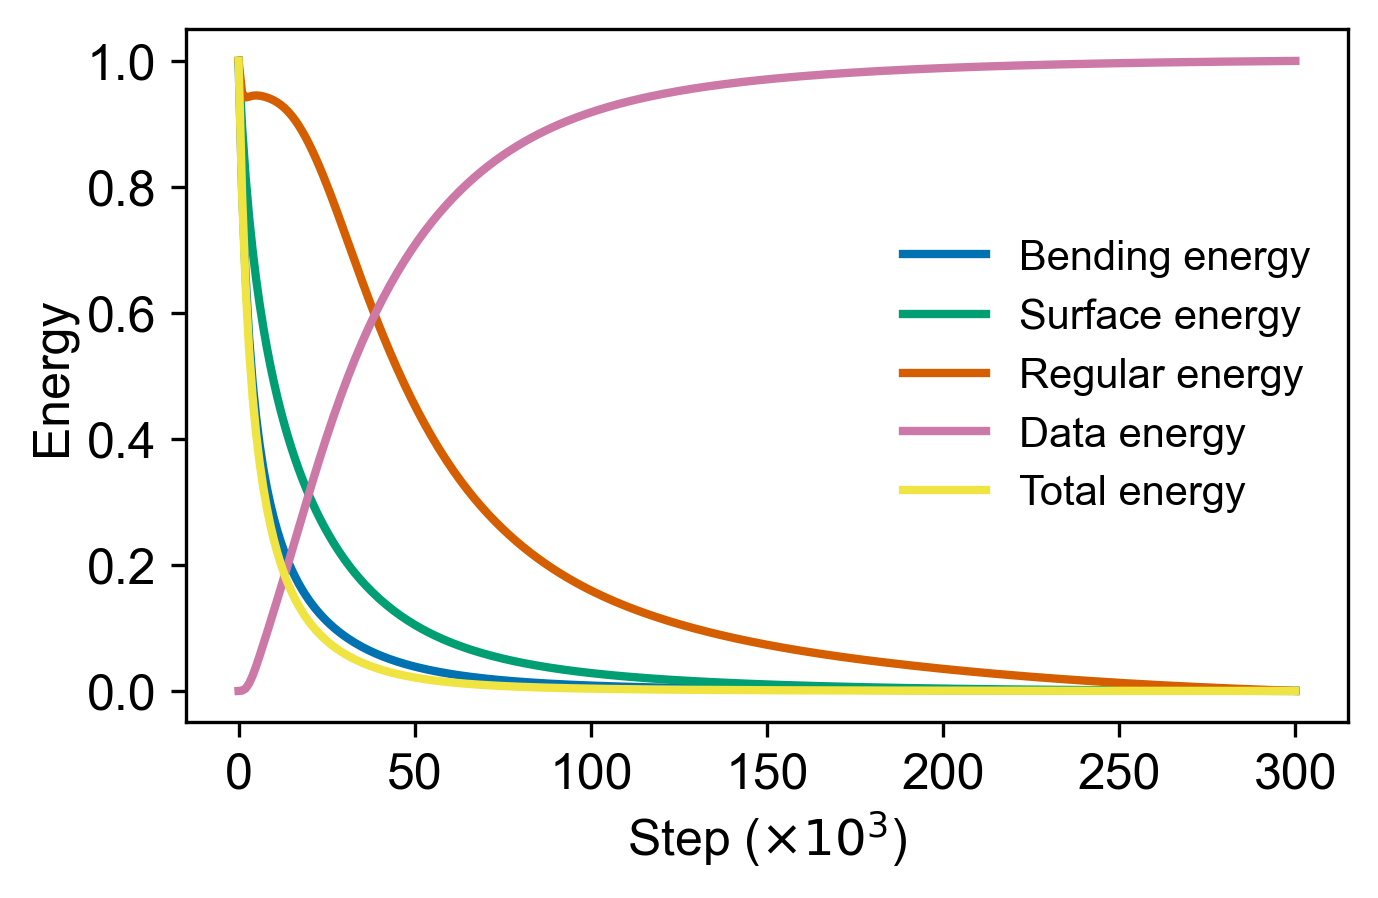

In [24]:
# Energy progress during relaxation

import numpy as np
import matplotlib.pyplot as plt
import os

# k_d = 10
# n_degree = 4
# noise_level = 0.1

file_path = f"dat/v2/img_{img_id:02d}_{N_node}.npz"
data = np.load(file_path)
energy = data['energy']

plt.figure(figsize=(5, 3))

energy_sum = energy.sum(axis=1)

plt.plot((energy[:, 0] - np.min(energy[:, 0])) / (np.max(energy[:, 0]) - np.min(energy[:, 0])), label=f'Bending energy')
plt.plot((energy[:, 1] - np.min(energy[:, 1])) / (np.max(energy[:, 1]) - np.min(energy[:, 1])), label=f'Surface energy')
plt.plot((energy[:, 2] - np.min(energy[:, 2])) / (np.max(energy[:, 2]) - np.min(energy[:, 2])), label=f'Regular energy')
plt.plot((energy[:, 3] - np.min(energy[:, 3])) / (np.max(energy[:, 3]) - np.min(energy[:, 3])), label=f'Data energy')
plt.plot((energy_sum   - np.min(energy_sum  )) / (np.max(energy_sum  ) - np.min(energy_sum  )), label=f'Total energy')

# plt.plot(energy[:, 0], label=f'Bending energy')
# plt.plot(energy[:, 1], label=f'Surface energy')
# plt.plot(energy[:, 2], label=f'Regular energy')
# plt.plot(energy[:, 3], label=f'Data energy')
# plt.plot(energy_sum  , label=f'Total energy')

# plt.title(f"k_d = {k_d}, n = {n_degree}, sigma = {noise_level}")
plt.xlabel(r"Step ($\times 10^3$)")
plt.ylabel('Energy')
plt.legend()
plt.savefig(f"figures/v2/relax/energy_img{img_id:02d}_n{N_node}.png", dpi=300, bbox_inches='tight', pad_inches=0.4)
plt.show()


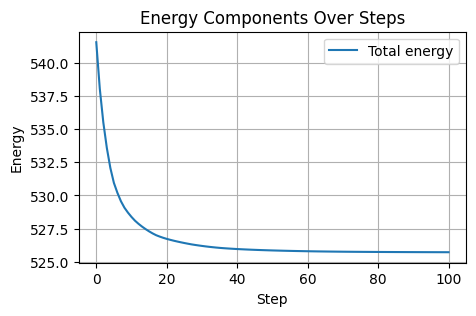

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

file_stem = 'Membrane_2018June_Tomo26_CME_Invagination'
N_node = 50
img_id = 1

file_path = os.path.join(f"dat/img_{img_id:02d}_{N_node}.npz")
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']

plt.figure(figsize=(5, 3))

energy_sum = energy.sum(axis=1)

# plt.plot(energy[:, 0], label=f'Bending energy')
# plt.plot(energy[:, 1], label=f'Surface energy')
# plt.plot(energy[:, 2], label=f'Regular energy')
# plt.plot(energy[:, 3], label=f'Datafid energy')

plt.plot(energy_sum, label=f'Total energy')

plt.title('Energy Components Over Steps')
plt.xlabel('Step')
plt.ylabel('Energy')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
energy_sum = [energy[:, i].sum() for i in range(4)]

### Addressing issue block

max_H:  0.08781366511435067
ave_H:  0.007837292985819307
cleng:  418.3097142973713
kappa:  12.400461074274398
sigma:  0.023905732184099176


Energy relaxation:   0%|          | 0/1 [00:00<?, ?it/s]

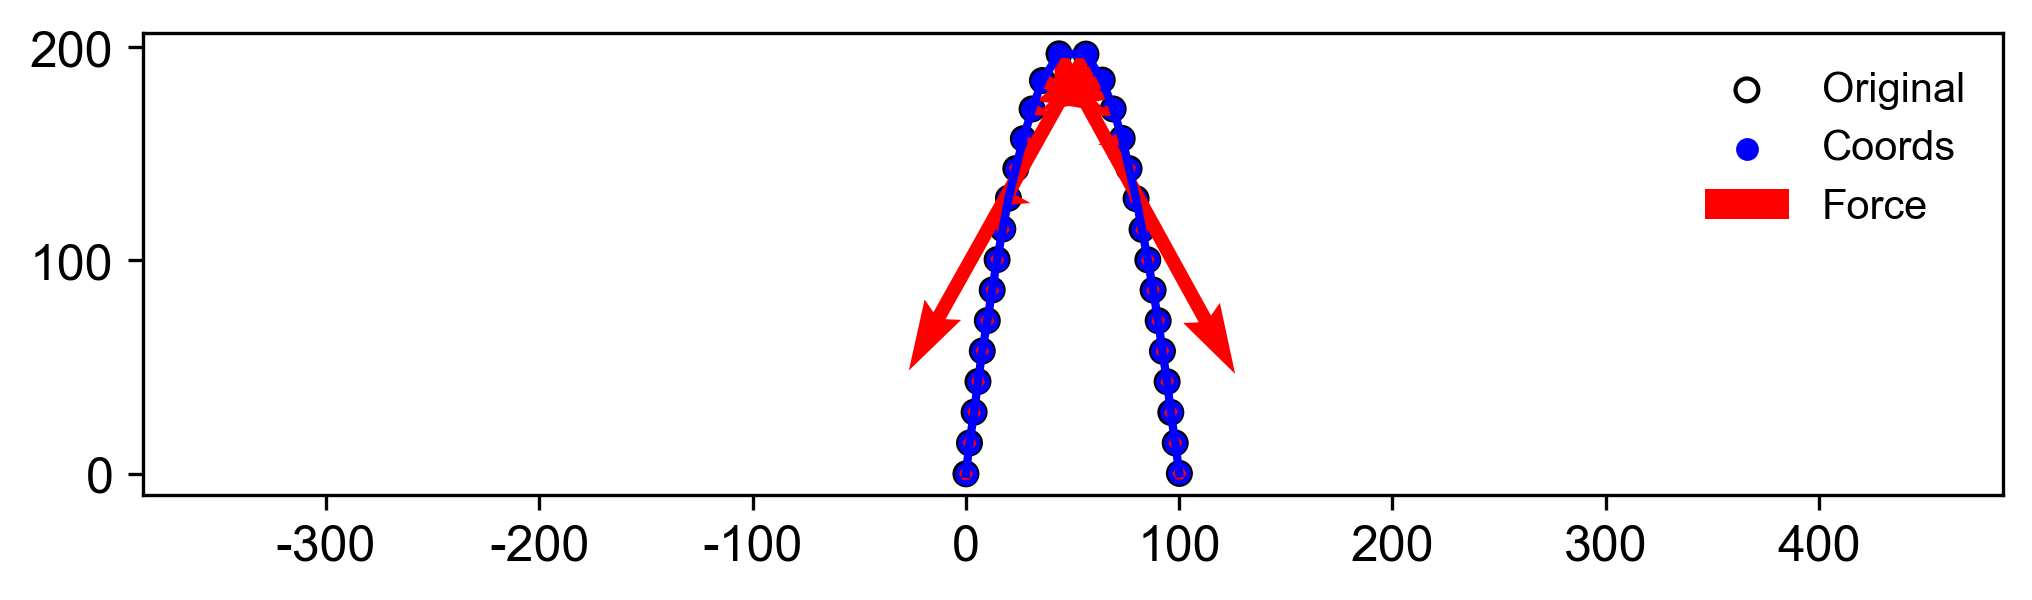

np.float64(0.001712972822784919)

In [9]:
from sample import make_parabola
import matplotlib.pyplot as plt
from variation_relax import relax_bending_log
import numpy as np

N_node = 30      
L_etoe = 100     
height = 200
noise_level = 0.1

ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif", noise_level = noise_level)

params = {
    "Kb"      : 10,       # bending term weight
    "Ks"      : 10,       # surface tension term weight
    "Kr"      : 10,       # regularization term weight
    "k_d"     : 1,        # data fidelity term weight 
    "n_degree": 4,        # degree of the data term
    "dt"      : 1e-4,     # time step for forward Eulear
    "n_iter"  : 1,        # total iteration of forward Eulear
    "boundary": "pinned", # boundary condition
    "del_save": 1e3,
}

output_keys = ["coords", "energy", "forces", "length", "curvat", "dtdist"]
result = dict(zip(output_keys, relax_bending_log(coords=ori_coords, data_points=ori_coords, **params)))

coords = result["coords"][0]
forces = result["forces"][0][1]


scale = 1
scale_factor = 1e5
x_ori = ori_coords[:, 0]
y_ori = ori_coords[:, 1]
x_coords = coords[:, 0]
y_coords = coords[:, 1]
x_forces = forces[:, 0] * scale_factor
y_forces = forces[:, 1] * scale_factor

plt.figure(figsize=(8, 2))
plt.scatter(x_ori, y_ori, color='black', facecolors='none', label='Original', s=30)
plt.scatter(x_coords, y_coords, color='blue', label='Coords', s=20) 
plt.plot(x_coords, y_coords, color='blue', linestyle='-', linewidth=2)

plt.quiver(x_coords, y_coords, x_forces, y_forces, color='red', angles='xy', scale_units='xy', scale=scale, label='Force')
   

plt.legend()
plt.axis('equal')  # Keep aspect ratio to 1:1

# plt.xlim(0, 100)
# plt.ylim(0, 200)


# Show the plot
plt.show()

np.max(np.sqrt(forces[:, 0]**2 + forces[:, 1]**2))

In [1]:
#TEST

from sample import make_parabola
from variation_relax import resample, relax_bending, relax_bending_log, preprocess_mesh
import os
import numpy as np
from pathlib import Path

## Parameters ##
N_node = 30        # number of vertices on the original parabola
L_etoe = 100       # end-to-end distance of the parabola
height = 200        # height of the parabola
noise_level = 0.1  # noise added to the oridinal parabola coordinate

ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif", noise_level = noise_level)

params = {
    "Kb"      : 10,       # bending term weight
    "Ks"      : 10,       # surface tension term weight
    "Kr"      : 10,       # regularization term weight
    "k_d"     : 1,        # data fidelity term weight 
    "n_degree": 4,        # degree of the data term
    "dt"      : 1e-4,     # time step for forward Eulear
    "n_iter"  : int(3e5), # total iteration of forward Eulear
    "boundary": "pinned", # boundary condition
    "del_save": 1e3,
}

output_keys = ["coords", "energy", "forces", "length", "curvat", "dtdist"]
result = dict(zip(output_keys, relax_bending_log(coords=ori_coords, data_points=ori_coords, **params)))

file_path = os.path.join(f"dat/v2/test.npz")
np.savez(file_path, ori_coords=ori_coords, **result)



max_H:  0.007837292985819307
cleng:  418.3097142973713
kappa:  1556.7894364539961
sigma:  0.023905732184099176


Energy relaxation:   0%|          | 0/300000 [00:00<?, ?it/s]

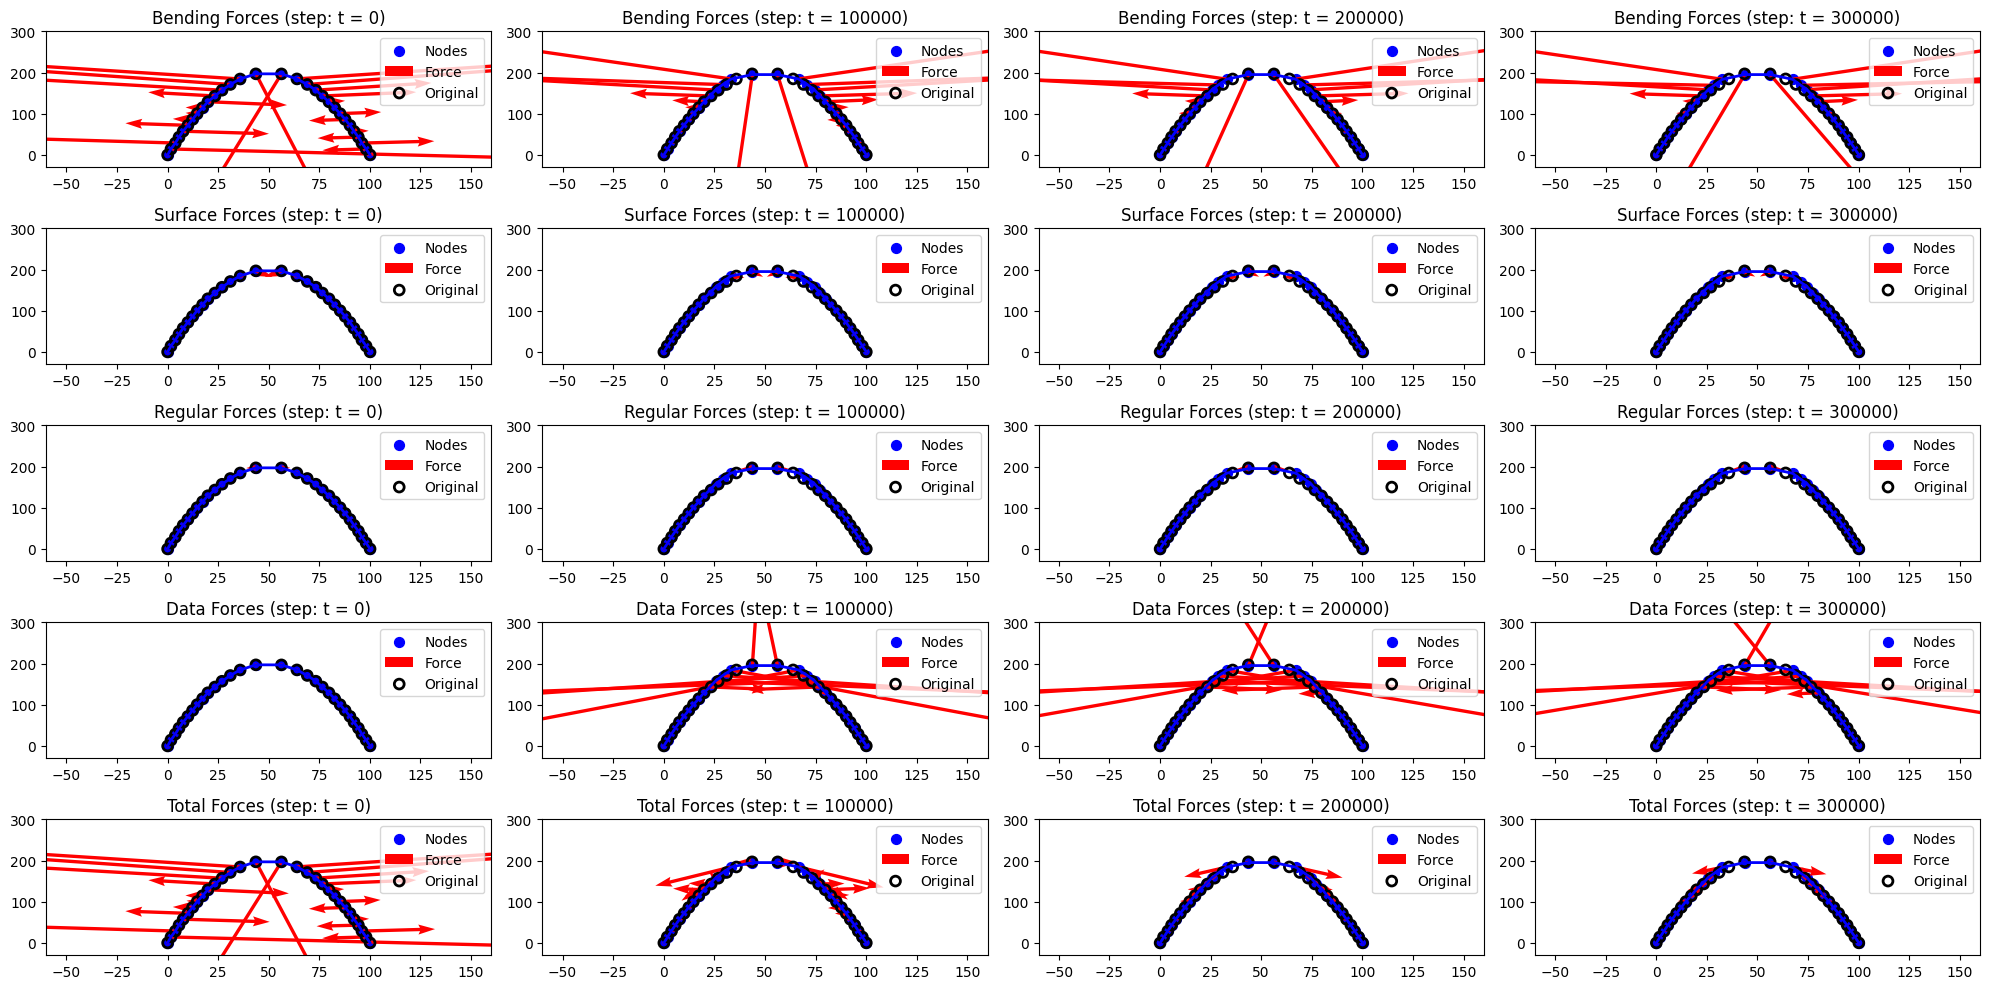

In [1]:
# Progress of the force field during relaxation

import matplotlib.pyplot as plt
import numpy as np
import os
from sample import plot_parabola_ax

tot_iter = 3e5
del_show = 1e5
del_save = 1e3

interval = int(del_show/del_save)
n_show = int(tot_iter/del_show)+1
fig, axes = plt.subplots(5, n_show, figsize=(20, 10))

file_path = f"dat/v2/test.npz"
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']

for idx in range(0, n_show):

    n_iter = del_show * idx
    i = interval * idx
    total_forces = forces[i, 0] + forces[i, 1] + forces[i, 2] + forces[i, 3]

    scale = 10
    
    plot_parabola_ax(coords[i], forces[i, 0], ax=axes[0, idx], n_iter=n_iter, force_type="Bending Forces", scale=scale, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 1], ax=axes[1, idx], n_iter=n_iter, force_type="Surface Forces", scale=scale, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 2], ax=axes[2, idx], n_iter=n_iter, force_type="Regular Forces", scale=scale, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 3], ax=axes[3, idx], n_iter=n_iter, force_type="Data Forces"   , scale=scale, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], total_forces, ax=axes[4, idx], n_iter=n_iter, force_type="Total Forces"  , scale=scale, ori_coords = ori_coords)

plt.tight_layout()
# plt.savefig(f"figures/spline_test/force_n{N_node}_{noise_level:.2f}".replace('.', '')+ f"_n{n_vertices:03d}_k{k_val}.png", dpi=300)
plt.show()


In [19]:
##TEST

from variation_relax import resample, relax_bending, relax_bending_log, preprocess_mesh, convert_unit
import os
import numpy as np
from pathlib import Path

# Data path
file = Path('coordinates/Membrane_2018June_Tomo26_CME_Invagination.txt')
img_id = 1

# Parameters
N_node = 30

params = {
    "Kb"      : 10,       # bending term weight
    "Ks"      : 10,       # surface tension term weight
    "Kr"      : 10,       # regularization term weight
    "k_d"     : 1,        # data fidelity term weight 
    "n_degree": 4,        # degree of the data term
    "dt"      : 1e-4,     # time step for forward Eulear
    "n_iter"  : int(3e5), # total iteration of forward Eulear
    "boundary": "pinned", # boundary condition
    "del_save": 1e3,
}

ori_coords, _ = preprocess_mesh(file, resample_geometry=True, n_vertices=N_node)
output_keys = ["coords", "energy", "forces", "length", "curvat", "dtdist"]
# result = dict(zip(output_keys, relax_bending_log(coords=ori_coords, data_points=ori_coords, **params)))

print(np.max(ori_coords[:,0]) - np.min(ori_coords[:,0]))
print(np.max(ori_coords[:,1]) - np.min(ori_coords[:,1]))


155.39999999999998
216.96511060704876


In [20]:
from sample import make_parabola
from variation_relax import resample, relax_bending, relax_bending_log, preprocess_mesh
import os
import numpy as np
from pathlib import Path

## Parameters ##
N_node = 30        # number of vertices on the original parabola
L_etoe = 100       # end-to-end distance of the parabola
height = 50        # height of the parabola
noise_level = 0.1  # noise added to the oridinal parabola coordinate

ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif", noise_level = noise_level)

params = {
    "Kb"      : 10,       # bending term weight
    "Ks"      : 10,       # surface tension term weight
    "Kr"      : 10,       # regularization term weight
    "k_d"     : 1,        # data fidelity term weight 
    "n_degree": 4,        # degree of the data term
    "dt"      : 1e-4,     # time step for forward Eulear
    "n_iter"  : int(3e5), # total iteration of forward Eulear
    "boundary": "pinned", # boundary condition
    "del_save": 1e3,
}

# output_keys = ["coords", "energy", "forces", "length", "curvat", "dtdist"]
# result = dict(zip(output_keys, relax_bending_log(coords=ori_coords, data_points=ori_coords, **params)))

print(np.max(ori_coords[:,0]) - np.min(ori_coords[:,0]))
print(np.max(ori_coords[:,1]) - np.min(ori_coords[:,1]))


100.05875340238386
49.934958394317725


In [15]:
print(ori_coords)

[[ 4.71435164e-02 -3.97840228e-02]
 [ 2.20471841e+00  4.57333950e+00]
 [ 4.88326289e+00  9.13534599e+00]
 [ 7.22799733e+00  1.35691310e+01]
 [ 9.82224269e+00  1.79170044e+01]
 [ 1.27490198e+01  2.21026821e+01]
 [ 1.56614250e+01  2.63114525e+01]
 [ 1.85981479e+01  3.03260161e+01]
 [ 2.19473545e+01  3.43433514e+01]
 [ 2.52346221e+01  3.81937304e+01]
 [ 2.93519909e+01  4.13855517e+01]
 [ 3.34162820e+01  4.43769367e+01]
 [ 3.78223784e+01  4.69910871e+01]
 [ 4.22608610e+01  4.86563381e+01]
 [ 4.74210891e+01  4.98951744e+01]
 [ 5.25457150e+01  4.97806795e+01]
 [ 5.75775589e+01  4.88501564e+01]
 [ 6.23018632e+01  4.69893018e+01]
 [ 6.68150284e+01  4.45091227e+01]
 [ 7.06083221e+01  4.13994586e+01]
 [ 7.45208448e+01  3.80387352e+01]
 [ 7.79886182e+01  3.41146029e+01]
 [ 8.13575419e+01  3.02180982e+01]
 [ 8.44798778e+01  2.62888894e+01]
 [ 8.74715117e+01  2.20600670e+01]
 [ 9.00587679e+01  1.78161707e+01]
 [ 9.28082929e+01  1.34999392e+01]
 [ 9.50783051e+01  9.02703683e+00]
 [ 9.76578732e+01  4